# LLM as a Judge: Evaluating VLM Outputs with Structured Responses

## Overview

When evaluating Vision-Language Models (VLMs) on tasks like people counting, object detection, or scene understanding, we face a common challenge: **how do we extract and validate structured information from free-form text responses?**

Traditional approaches using regex patterns quickly become unwieldy and fragile. Instead, we can use an **LLM as a judge** with structured outputs to:

1. Parse VLM responses reliably
2. Extract specific information (e.g., counts, classifications)
3. Validate against ground truth
4. Provide evaluation metrics

This notebook demonstrates:
- Using VLMs (Claude/Qwen) via OpenRouter for vision tasks
- Implementing LLM-as-judge with structured outputs via JSON mode
- Comparing regex vs LLM judge approaches
- Computing evaluation metrics

## Setup and Dependencies

### API Key Configuration

Before running this notebook, you need to set up your OpenRouter API key:

1. **Get an API key**: Visit [https://openrouter.ai/keys](https://openrouter.ai/keys) to create an account and get your API key

2. **Create a `.env` file** in the root of your project directory with the following content:
   ```bash
   # OpenRouter API Configuration
   # Get your API key from: https://openrouter.ai/keys
   OPENROUTER_API_KEY=sk-or-v1-your-actual-key-here
   ```

3. **Important**: Make sure `.env` is in your `.gitignore` to avoid committing your API key to version control

In [23]:
# Install required packages (uncomment if needed)
# !pip install pillow requests pydantic numpy pandas matplotlib python-dotenv

In [24]:
import os
import json
import re
from pathlib import Path
from typing import List, Dict, Optional, Literal
from io import BytesIO

import requests
from PIL import Image
from pydantic import BaseModel, Field
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# OpenRouter configuration
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"

if not OPENROUTER_API_KEY:
    print("⚠️  WARNING: OPENROUTER_API_KEY not found in environment variables!")
    print("Please set it in your .env file")
else:
    print("✓ OpenRouter API key loaded successfully")

✓ OpenRouter API key loaded successfully


## Part 1: Understanding the Evaluation Tasks

We'll evaluate VLMs on several common computer vision tasks:

### Task 1: People Counting
Count the number of people visible in an image. This is challenging because:
- People may be partially occluded
- Lighting and angles vary
- VLM responses vary in format ("I see 3 people" vs "There are three individuals" vs "Count: 3")

### Task 2: Scene Classification  
Identify the type of location or scene. Challenges include:
- Ambiguous scenes that could fit multiple categories
- Varying levels of detail in VLM responses
- Different terminology for the same concept

### Task 3: Object Detection
Identify specific objects in the image. Complex because:
- Multiple objects may be present
- Similar objects (car vs truck)
- VLM may use different names for objects

Let's create our evaluation dataset with diverse examples:

In [25]:
# Evaluation dataset with diverse tasks and images
# Note: We deliberately use prompts that encourage varied response formats
# to demonstrate why regex-based parsing is fragile
evaluation_dataset = [
    # People counting tasks - varied prompts to get different response formats
    {
        "id": "people_001",
        "image_url": "https://images.unsplash.com/photo-1529156069898-49953e39b3ac?w=800",
        "task": "people_count",
        "ground_truth": 2,
        "prompt": "Describe this scene and mention how many people you see.",  # Encourages narrative response
        "description": "Gym scene with people exercising"
    },
    {
        "id": "people_002",
        "image_url": "https://images.unsplash.com/photo-1543269865-cbf427effbad?w=800",
        "task": "people_count",
        "ground_truth": 4,
        "prompt": "What's happening in this image? Include the number of people.",  # Mixed format
        "description": "Group of people running outdoors"
    },
    {
        "id": "people_003",
        "image_url": "https://images.unsplash.com/photo-1511632765486-a01980e01a18?w=800",
        "task": "people_count",
        "ground_truth": 3,
        "prompt": "Tell me about this photo, specifically mentioning the count of people present.",
        "description": "Small group photo"
    },
    # Scene classification tasks
    {
        "id": "scene_001",
        "image_url": "https://images.unsplash.com/photo-1555396273-367ea4eb4db5?w=800",
        "task": "scene_classification",
        "ground_truth": "restaurant",
        "prompt": "Describe the type of venue shown here.",
        "description": "Restaurant interior"
    },
    {
        "id": "scene_002",
        "image_url": "https://images.unsplash.com/photo-1497366216548-37526070297c?w=800",
        "task": "scene_classification",
        "ground_truth": "office",
        "prompt": "What kind of space is this?",
        "description": "Modern office space"
    },
    {
        "id": "scene_003",
        "image_url": "https://images.unsplash.com/photo-1540553016722-983e48a2cd10?w=800",
        "task": "scene_classification",
        "ground_truth": "beach",
        "prompt": "Identify the location type.",
        "description": "Beach scene"
    },
    # Object detection tasks - require structured list output
    {
        "id": "object_001",
        "image_url": "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=800",
        "task": "object_detection",
        "ground_truth": ["cat"],
        "prompt": "What animals can you see?",
        "description": "Cat portrait"
    },
    {
        "id": "object_002",
        "image_url": "https://images.unsplash.com/photo-1484480974693-6ca0a78fb36b?w=800",
        "task": "object_detection",
        "ground_truth": ["laptop", "phone", "coffee"],
        "prompt": "Describe what you see on the desk or table.",
        "description": "Workspace with laptop"
    },
]

print(f"Dataset: {len(evaluation_dataset)} images")
print(f"Tasks: {', '.join(set(item['task'] for item in evaluation_dataset))}")
print(f"\nTask distribution:")
for task in set(item['task'] for item in evaluation_dataset):
    count = sum(1 for item in evaluation_dataset if item['task'] == task)
    print(f"  {task}: {count} images")

Dataset: 8 images
Tasks: scene_classification, people_count, object_detection

Task distribution:
  scene_classification: 3 images
  people_count: 3 images
  object_detection: 2 images


### Visualize ALL Images

Let's display all images from our evaluation dataset:

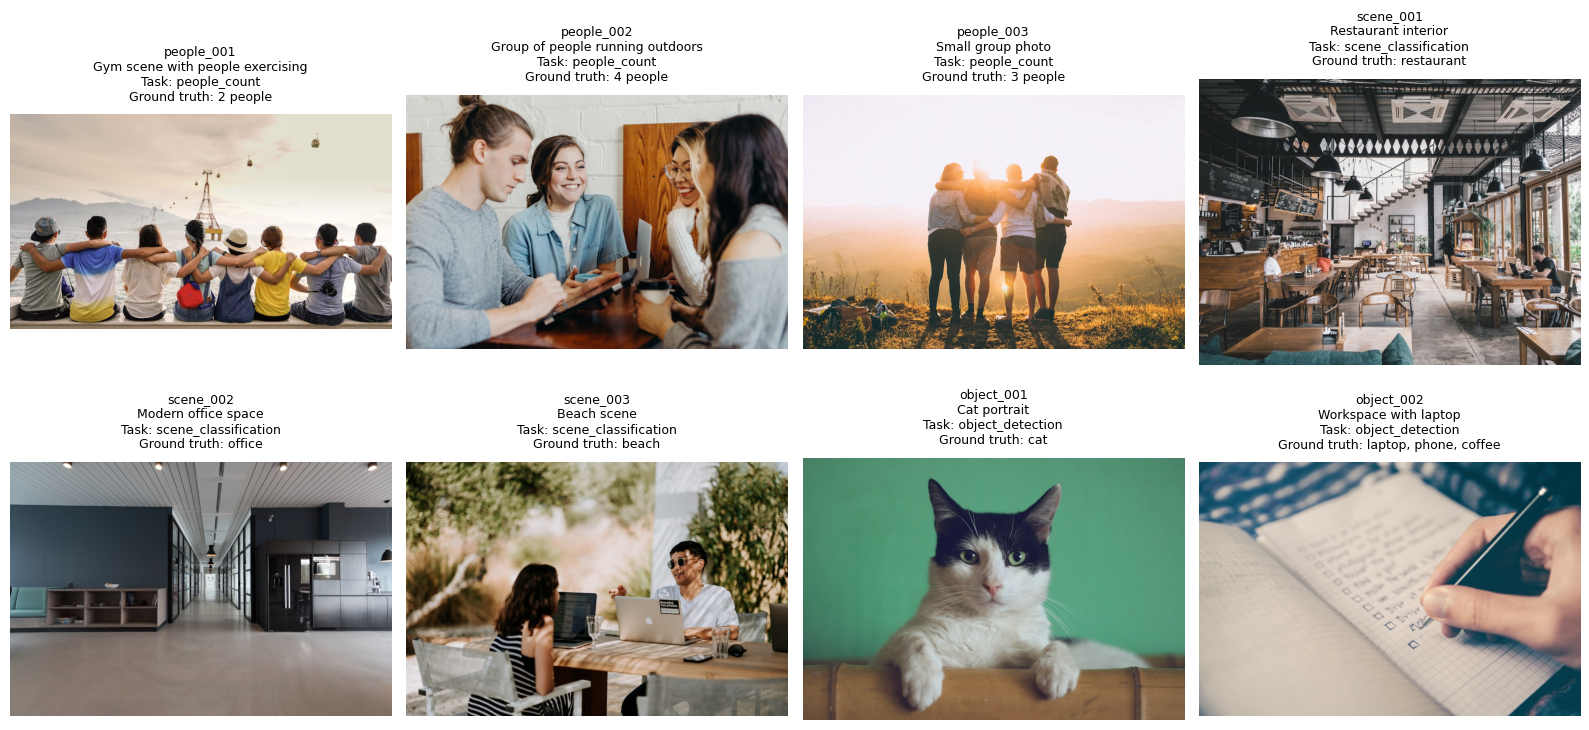

In [26]:
def display_all_images(dataset):
    """Display all images from the dataset in a grid."""
    num_images = len(dataset)
    cols = 4
    rows = (num_images + cols - 1) // cols  # Ceiling division
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.ravel()
    
    for idx, item in enumerate(dataset):
        try:
            response = requests.get(item['image_url'])
            img = Image.open(BytesIO(response.content))
            
            axes[idx].imshow(img)
            axes[idx].axis('off')
            
            title = f"{item['id']}\n{item['description']}\nTask: {item['task']}"
            if item['task'] == 'people_count':
                title += f"\nGround truth: {item['ground_truth']} people"
            elif item['task'] == 'scene_classification':
                title += f"\nGround truth: {item['ground_truth']}"
            else:
                title += f"\nGround truth: {', '.join(item['ground_truth'])}"
            
            axes[idx].set_title(title, fontsize=9, pad=10)
        except Exception as e:
            axes[idx].text(0.5, 0.5, f"Error loading image:\n{str(e)}", 
                          ha='center', va='center')
            axes[idx].axis('off')
    
    # Hide any unused subplots
    for idx in range(num_images, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

display_all_images(evaluation_dataset)

## Part 2: Query VLM and See Raw Outputs

First, let's see what the VLM actually returns. This will help us understand why parsing is challenging.

In [27]:
def query_vlm_openrouter(image_url: str, prompt: str, model: str = "anthropic/claude-3.5-sonnet") -> str:
    """
    Query a VLM via OpenRouter API.
    """
    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json"
    }
    
    payload = {
        "model": model,
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": image_url}}
                ]
            }
        ],
        "max_tokens": 300
    }
    
    response = requests.post(
        f"{OPENROUTER_BASE_URL}/chat/completions",
        headers=headers,
        json=payload
    )
    response.raise_for_status()
    
    result = response.json()
    return result['choices'][0]['message']['content']

### Get VLM Responses for All Images

Let's query the VLM and see the raw responses:

In [28]:
# Choose VLM model (options: "anthropic/claude-3.5-sonnet", "qwen/qwen-vl-max")
VLM_MODEL = "anthropic/claude-3.5-sonnet"

print(f"Using VLM: {VLM_MODEL}\n")
print("="*80)

# Get VLM responses
for item in evaluation_dataset:
    print(f"\n[{item['id']}] {item['description']}")
    print(f"Task: {item['task']}")
    print(f"Prompt: {item['prompt']}")
    print(f"Ground Truth: {item['ground_truth']}")
    
    try:
        vlm_response = query_vlm_openrouter(
            image_url=item['image_url'],
            prompt=item['prompt'],
            model=VLM_MODEL
        )
        item['vlm_response'] = vlm_response
        print(f"\nVLM Response:\n{vlm_response}")
    except Exception as e:
        print(f"\nError: {str(e)}")
        item['vlm_response'] = f"ERROR: {str(e)}"
    
    print("="*80)

print("\nAll VLM responses collected!")

Using VLM: anthropic/claude-3.5-sonnet


[people_001] Gym scene with people exercising
Task: people_count
Prompt: Describe this scene and mention how many people you see.
Ground Truth: 2

VLM Response:
This is a heartwarming scene showing a group of 9 people sitting in a row with their arms around each other's shoulders, facing a scenic view. They appear to be sitting along what might be a waterfront or pier. In the background, you can see cable cars or gondolas suspended in the air and mountains in the distance. The people are wearing casual summer attire including t-shirts, hats, and comfortable clothing in various colors like yellow, blue, and grey. The image captures a moment of unity and friendship as they take in the view together. The lighting suggests it might be around sunset or early evening.

[people_002] Group of people running outdoors
Task: people_count
Prompt: What's happening in this image? Include the number of people.
Ground Truth: 4

VLM Response:
This image shows 4 

## Part 3: The Problem with Regex - No Type Safety or Structure Validation

The fundamental issue with regex isn't just about extracting values—it's about **type safety** and **structural validation**. Let's see the problems:

### Problem 1: No Type Guarantees
Regex can extract a string, but can't ensure it's the right type (int, list, enum, etc.)

### Problem 2: No Structure Validation  
Regex can't validate complex nested structures or ensure all required fields are present

### Problem 3: No Semantic Understanding
Regex can't understand context, confidence, or provide explanations

Let's see regex in action:

In [29]:
def regex_extract_count(response: str) -> Optional[int]:
    """
    Attempt to extract a count using regex patterns.
    This shows how fragile regex-based extraction can be.
    """
    if not response or response.startswith("ERROR"):
        return None
        
    patterns = [
        r'(\d+)\s+(?:people|persons|individuals)',
        r'(?:count|total)\s*:?\s*(\d+)',
        r'(?:there are|i see|i count)\s*(\d+)',
        r'number of people\s*:?\s*(\d+)',
        r'(?:^|\s)(\d+)(?:$|\s)',  # Just a number
    ]
    
    for pattern in patterns:
        match = re.search(pattern, response.lower())
        if match:
            return int(match.group(1))
    
    return None

def regex_extract_scene(response: str) -> Optional[str]:
    """Extract scene type - even more fragile!"""
    if not response or response.startswith("ERROR"):
        return None
    
    # Try to extract first word or phrase
    words = response.strip().split()
    if words:
        return words[0].lower().strip('.,!?')
    return None

In [30]:
# Try regex extraction - showing its limitations
print("REGEX EXTRACTION ATTEMPTS")
print("="*80)
print("\nNotice the problems:")
print("1. Regex extracts raw values with NO type checking")
print("2. NO validation that the value makes sense")
print("3. NO confidence scores or explanations")
print("4. NO structured error categorization")
print("="*80)

for item in evaluation_dataset:
    if item['task'] == 'people_count':
        extracted = regex_extract_count(item['vlm_response'])
        correct = extracted == item['ground_truth'] if extracted else False
        
        print(f"\n[{item['id']}]")
        print(f"VLM Response: {item['vlm_response'][:150]}...")
        print(f"Ground Truth: {item['ground_truth']} (type: {type(item['ground_truth']).__name__})")
        print(f"Regex Extracted: {extracted} (type: {type(extracted).__name__ if extracted else 'None'})")
        print(f"❌ Correct: {'✓' if correct else '✗'}")
        print(f"❌ Type validated: No")
        print(f"❌ Confidence score: Not available")
        print(f"❌ Explanation: Not available")

print("\n" + "="*80)
print("Key Problem: Regex gives you a raw value with ZERO guarantees about:")
print("  - Type correctness (is it really an int?)")
print("  - Semantic validity (does the number make sense?)")  
print("  - Confidence (how sure are we?)")
print("  - Structure (for complex outputs like lists/objects)")
print("="*80)

REGEX EXTRACTION ATTEMPTS

Notice the problems:
1. Regex extracts raw values with NO type checking
2. NO validation that the value makes sense
3. NO confidence scores or explanations
4. NO structured error categorization

[people_001]
VLM Response: This is a heartwarming scene showing a group of 9 people sitting in a row with their arms around each other's shoulders, facing a scenic view. They ap...
Ground Truth: 2 (type: int)
Regex Extracted: 9 (type: int)
❌ Correct: ✗
❌ Type validated: No
❌ Confidence score: Not available
❌ Explanation: Not available

[people_002]
VLM Response: This image shows 4 people engaged in what appears to be a casual business meeting or study group. They are seated around a table and appear to be look...
Ground Truth: 4 (type: int)
Regex Extracted: 4 (type: int)
❌ Correct: ✓
❌ Type validated: No
❌ Confidence score: Not available
❌ Explanation: Not available

[people_003]
VLM Response: This photo shows four people standing together in a row, arms around each o

## Part 4: LLM Judge with Structured Outputs

Now let's implement the proper solution using JSON mode for structured outputs.

### Define Pydantic Schemas

In [31]:
class ComprehensiveEvaluation(BaseModel):
    """Comprehensive evaluation with correctness assessment."""
    extracted_value: str = Field(
        description="The extracted answer from the VLM response (as a string)"
    )
    is_correct: bool = Field(
        description="Whether the extracted value matches the ground truth"
    )
    confidence: Literal["high", "medium", "low"] = Field(
        description="Confidence level in the evaluation"
    )
    explanation: str = Field(
        description="Detailed explanation of the evaluation"
    )
    error_type: Optional[str] = Field(
        default=None,
        description="If incorrect, categorize the error type (e.g., 'undercount', 'overcount', 'misclassification', 'parsing_error')"
    )

class ObjectDetectionEvaluation(BaseModel):
    """Evaluation for object detection tasks."""
    detected_objects: List[str] = Field(
        description="List of objects detected by the VLM"
    )
    all_objects_found: bool = Field(
        description="Whether all ground truth objects were detected"
    )
    missing_objects: List[str] = Field(
        description="Objects in ground truth but not detected"
    )
    extra_objects: List[str] = Field(
        description="Objects detected but not in ground truth"
    )
    confidence: Literal["high", "medium", "low"] = Field(
        description="Confidence level in the evaluation"
    )
    explanation: str = Field(
        description="Explanation of the evaluation"
    )

### Implement LLM Judge Using Structured JSON Output

Using OpenRouter's JSON mode for guaranteed structured outputs:

In [32]:
def llm_judge_structured(
    vlm_response: str,
    ground_truth: any,
    task_type: str,
    response_model: type[BaseModel],
    judge_model: str = "anthropic/claude-3.5-sonnet"
) -> BaseModel:
    """
    Use LLM as judge with structured JSON outputs via OpenRouter.
    
    Args:
        vlm_response: The text response from the VLM
        ground_truth: The ground truth value
        task_type: Description of the task (e.g., 'people counting')
        response_model: Pydantic model for structured output
        judge_model: Model to use as judge
    
    Returns:
        Structured evaluation result
    """
    # Get JSON schema from Pydantic model
    schema = response_model.model_json_schema()
    
    prompt = f"""You are evaluating a Vision-Language Model's response for a {task_type} task.

VLM Response:
{vlm_response}

Ground Truth: {ground_truth}

Please extract the answer from the VLM response and evaluate it against the ground truth.
Respond with ONLY a JSON object matching this schema:
{json.dumps(schema, indent=2)}

Do not include any other text or explanation outside the JSON object."""

    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json"
    }
    
    payload = {
        "model": judge_model,
        "messages": [{"role": "user", "content": prompt}],
        "response_format": {"type": "json_object"},
        "max_tokens": 1024
    }
    
    response = requests.post(
        f"{OPENROUTER_BASE_URL}/chat/completions",
        headers=headers,
        json=payload
    )
    response.raise_for_status()
    
    result = response.json()
    result_json = json.loads(result['choices'][0]['message']['content'])
    
    return response_model(**result_json)

## Part 5: Run Complete Evaluation

Now let's evaluate all images using both approaches:

In [33]:
JUDGE_MODEL = "anthropic/claude-3.5-sonnet"  # Judge model via OpenRouter

print("COMPLETE EVALUATION: Regex vs LLM Judge")
print("="*80)

comparison_results = []

for item in evaluation_dataset:
    print(f"\n[{item['id']}] {item['task']}")
    print(f"Ground Truth: {item['ground_truth']}")
    
    result = {
        'id': item['id'],
        'task': item['task'],
        'description': item['description'],
        'ground_truth': item['ground_truth'],
        'vlm_response': item['vlm_response'][:200] if len(item['vlm_response']) > 200 else item['vlm_response']
    }
    
    # Regex extraction (only for simple tasks)
    if item['task'] == 'people_count':
        regex_result = regex_extract_count(item['vlm_response'])
        result['regex_extracted'] = regex_result
        result['regex_correct'] = regex_result == item['ground_truth'] if regex_result is not None else False
        print(f"Regex: extracted={regex_result}, correct={result['regex_correct']}")
    
    # LLM Judge with structured output
    try:
        if item['task'] == 'object_detection':
            judge_result = llm_judge_structured(
                vlm_response=item['vlm_response'],
                ground_truth=item['ground_truth'],
                task_type="object detection",
                response_model=ObjectDetectionEvaluation,
                judge_model=JUDGE_MODEL
            )
            result['llm_extracted'] = ', '.join(judge_result.detected_objects)
            result['llm_correct'] = judge_result.all_objects_found
            result['llm_confidence'] = judge_result.confidence
            result['llm_explanation'] = judge_result.explanation
            result['llm_missing'] = ', '.join(judge_result.missing_objects)
            result['llm_extra'] = ', '.join(judge_result.extra_objects)
        else:
            task_name = "people counting" if item['task'] == 'people_count' else "scene classification"
            judge_result = llm_judge_structured(
                vlm_response=item['vlm_response'],
                ground_truth=item['ground_truth'],
                task_type=task_name,
                response_model=ComprehensiveEvaluation,
                judge_model=JUDGE_MODEL
            )
            result['llm_extracted'] = judge_result.extracted_value
            result['llm_correct'] = judge_result.is_correct
            result['llm_confidence'] = judge_result.confidence
            result['llm_explanation'] = judge_result.explanation
            result['llm_error_type'] = judge_result.error_type
        
        print(f"LLM Judge: extracted={result['llm_extracted']}, correct={result['llm_correct']}, confidence={result['llm_confidence']}")
        print(f"Explanation: {result['llm_explanation'][:100]}...")
        
    except Exception as e:
        print(f"LLM Judge Error: {str(e)}")
        result['llm_extracted'] = "ERROR"
        result['llm_correct'] = False
        result['llm_confidence'] = "low"
        result['llm_explanation'] = str(e)
    
    comparison_results.append(result)

print("\n" + "="*80)
print("Evaluation complete!")

COMPLETE EVALUATION: Regex vs LLM Judge

[people_001] people_count
Ground Truth: 2
Regex: extracted=9, correct=False
LLM Judge: extracted=9, correct=False, confidence=high
Explanation: The VLM clearly stated '9 people' in its response, while the ground truth is 2. This is an unambiguo...

[people_002] people_count
Ground Truth: 4
Regex: extracted=4, correct=True
LLM Judge: extracted=4, correct=True, confidence=high
Explanation: The VLM response clearly states 'This image shows 4 people' at the beginning of its description, and...

[people_003] people_count
Ground Truth: 3
Regex: extracted=None, correct=False
LLM Judge: extracted=4, correct=False, confidence=high
Explanation: The VLM clearly states 'four people' in its response while the ground truth indicates there are 3 pe...

[scene_001] scene_classification
Ground Truth: restaurant
LLM Judge: extracted=café, correct=False, confidence=high
Explanation: The VLM identifies the space primarily as a 'café or coffee shop', while the groun

## Part 6: Analysis and Metrics

In [34]:
# Create DataFrame
df_results = pd.DataFrame(comparison_results)

# Display summary
print("\nRESULTS SUMMARY")
print("="*80)

display_cols = ['id', 'task', 'ground_truth', 'llm_extracted', 'llm_correct', 'llm_confidence']
if 'regex_extracted' in df_results.columns:
    display_cols.insert(4, 'regex_extracted')
    display_cols.insert(5, 'regex_correct')

print(df_results[display_cols].to_string(index=False))


RESULTS SUMMARY
        id                 task            ground_truth                llm_extracted  regex_extracted regex_correct  llm_correct llm_confidence
people_001         people_count                       2                            9              9.0         False        False           high
people_002         people_count                       4                            4              4.0          True         True           high
people_003         people_count                       3                            4              NaN         False        False           high
 scene_001 scene_classification              restaurant                         café              NaN           NaN        False           high
 scene_002 scene_classification                  office                       office              NaN           NaN         True           high
 scene_003 scene_classification                   beach outdoor workspace/café patio              NaN           NaN    

In [35]:
# Calculate metrics
print("\n" + "="*80)
print("ACCURACY METRICS")
print("="*80)

# Overall accuracy
llm_accuracy = df_results['llm_correct'].mean()
print(f"\nLLM Judge Overall Accuracy: {llm_accuracy:.1%}")

# Per-task accuracy
print("\nAccuracy by Task:")
for task in df_results['task'].unique():
    task_df = df_results[df_results['task'] == task]
    task_acc = task_df['llm_correct'].mean()
    print(f"  {task}: {task_acc:.1%} ({task_df['llm_correct'].sum()}/{len(task_df)} correct)")

# Regex accuracy (where applicable)
if 'regex_correct' in df_results.columns:
    regex_df = df_results[df_results['regex_extracted'].notna()]
    if len(regex_df) > 0:
        regex_accuracy = regex_df['regex_correct'].mean()
        print(f"\nRegex Extraction Accuracy: {regex_accuracy:.1%}")
        print(f"  Successful extractions: {regex_df['regex_extracted'].notna().sum()}/{len(df_results)} attempts")

# Confidence distribution
print("\nLLM Judge Confidence Distribution:")
conf_dist = df_results['llm_confidence'].value_counts()
for conf, count in conf_dist.items():
    print(f"  {conf}: {count} ({count/len(df_results)*100:.1f}%)")


ACCURACY METRICS

LLM Judge Overall Accuracy: 37.5%

Accuracy by Task:
  people_count: 33.3% (1/3 correct)
  scene_classification: 33.3% (1/3 correct)
  object_detection: 50.0% (1/2 correct)

Regex Extraction Accuracy: 50.0%
  Successful extractions: 2/8 attempts

LLM Judge Confidence Distribution:
  high: 8 (100.0%)


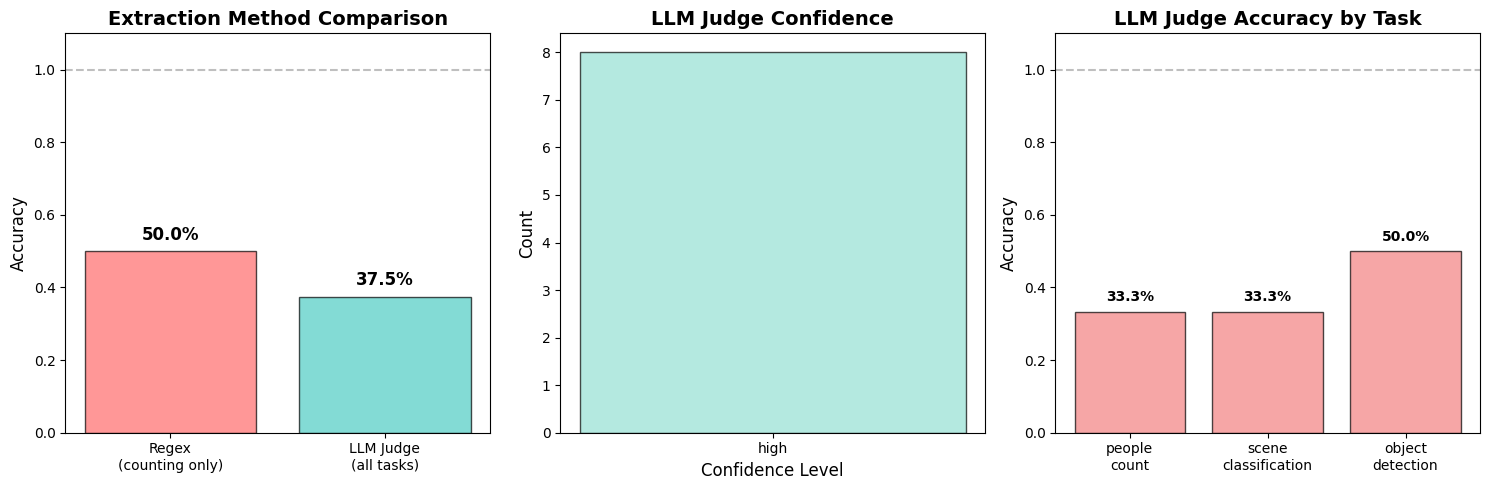

In [36]:
# Visualizations
fig = plt.figure(figsize=(15, 5))

# Plot 1: Accuracy comparison
if 'regex_correct' in df_results.columns and len(df_results[df_results['regex_extracted'].notna()]) > 0:
    ax1 = plt.subplot(1, 3, 1)
    methods = ['Regex\n(counting only)', 'LLM Judge\n(all tasks)']
    accuracies = [
        df_results[df_results['regex_extracted'].notna()]['regex_correct'].mean(),
        llm_accuracy
    ]
    colors = ['#FF6B6B', '#4ECDC4']
    
    bars = ax1.bar(methods, accuracies, color=colors, alpha=0.7, edgecolor='black')
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title('Extraction Method Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylim([0, 1.1])
    ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
    
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{acc:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    # Plot 2: Confidence distribution
    ax2 = plt.subplot(1, 3, 2)
else:
    ax2 = plt.subplot(1, 2, 1)

conf_counts = df_results['llm_confidence'].value_counts()
ax2.bar(conf_counts.index, conf_counts.values, color='#95E1D3', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Confidence Level', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('LLM Judge Confidence', fontsize=14, fontweight='bold')

# Plot 3: Accuracy by task
if 'regex_correct' in df_results.columns and len(df_results[df_results['regex_extracted'].notna()]) > 0:
    ax3 = plt.subplot(1, 3, 3)
else:
    ax3 = plt.subplot(1, 2, 2)

task_accuracies = []
task_names = []
for task in df_results['task'].unique():
    task_df = df_results[df_results['task'] == task]
    task_accuracies.append(task_df['llm_correct'].mean())
    task_names.append(task.replace('_', '\n'))

bars = ax3.bar(task_names, task_accuracies, color='#F38181', alpha=0.7, edgecolor='black')
ax3.set_ylabel('Accuracy', fontsize=12)
ax3.set_title('LLM Judge Accuracy by Task', fontsize=14, fontweight='bold')
ax3.set_ylim([0, 1.1])
ax3.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

for bar, acc in zip(bars, task_accuracies):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{acc:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## Detailed Error Analysis

In [37]:
print("\nDETAILED ERROR ANALYSIS")
print("="*80)

incorrect_items = df_results[~df_results['llm_correct']]

if len(incorrect_items) > 0:
    print(f"\nFound {len(incorrect_items)} incorrect evaluations:\n")
    for _, item in incorrect_items.iterrows():
        print(f"ID: {item['id']} ({item['task']})")
        print(f"Description: {item['description']}")
        print(f"Ground Truth: {item['ground_truth']}")
        print(f"LLM Extracted: {item['llm_extracted']}")
        if 'llm_error_type' in item and item['llm_error_type']:
            print(f"Error Type: {item['llm_error_type']}")
        print(f"Explanation: {item['llm_explanation']}")
        print(f"VLM Response: {item['vlm_response']}")
        print("-" * 80)
else:
    print("\nAll evaluations were correct!")


DETAILED ERROR ANALYSIS

Found 5 incorrect evaluations:

ID: people_001 (people_count)
Description: Gym scene with people exercising
Ground Truth: 2
LLM Extracted: 9
Error Type: overcount
Explanation: The VLM clearly stated '9 people' in its response, while the ground truth is 2. This is an unambiguous difference between the extracted count and the ground truth.
VLM Response: This is a heartwarming scene showing a group of 9 people sitting in a row with their arms around each other's shoulders, facing a scenic view. They appear to be sitting along what might be a waterfron
--------------------------------------------------------------------------------
ID: people_003 (people_count)
Description: Small group photo
Ground Truth: 3
LLM Extracted: 4
Error Type: overcount
Explanation: The VLM clearly states 'four people' in its response while the ground truth indicates there are 3 people. The response is unambiguous in its count but incorrect.
VLM Response: This photo shows four people stan

## Key Takeaways

### Why LLM-as-Judge with Structured Outputs is Superior:

#### 1. **Type Safety** 🎯
- Pydantic models enforce types: `int` for counts, `List[str]` for objects, `Literal["high", "medium", "low"]` for confidence
- Regex gives you strings—no type guarantees, no validation
- Example: LLM judge ensures `confidence` is ONLY "high", "medium", or "low", not "very confident" or typos

#### 2. **Structural Validation** 🏗️
- Complex nested structures are validated automatically
- Object detection returns `detected_objects`, `missing_objects`, `extra_objects` as separate typed fields
- Regex can't handle nested or multi-field outputs without becoming unmaintainable

#### 3. **Rich Metadata** 📊
- Every response includes confidence levels, explanations, and error categorization
- These aren't optional—they're enforced by the schema
- Impossible to achieve with regex without writing hundreds of patterns

#### 4. **Semantic Understanding** 🧠
- LLM judge understands context: "coffee shop" vs "restaurant" are both food establishments
- Can categorize errors: "overcount" vs "undercount" vs "misclassification"
- Regex has zero semantic understanding

#### 5. **Maintainability** 🔧
- Add new fields to Pydantic model → automatic validation
- Regex: add new pattern → debug interactions with existing patterns → hope it works

#### 6. **Explainability** 💡
- Every evaluation includes human-readable explanations
- Critical for debugging, auditing, and improving your system
- Regex: you get a match or no match, good luck figuring out why

### The Real Power: Guaranteed Structure

The game-changer isn't just "better parsing"—it's **compile-time guarantees** about your data structure:

```python
# With Pydantic/LLM Judge:
result: ComprehensiveEvaluation = llm_judge_structured(...)
# TypeScript/IDE knows:
# - result.confidence is Literal["high", "medium", "low"]
# - result.is_correct is bool
# - result.explanation is str
# - ALL fields are present and correctly typed

# With Regex:
count: Optional[int] = regex_extract_count(...)
# You get:
# - Maybe an int, maybe None, maybe wrong
# - No other metadata
# - No guarantees
```

### When to Use Each Approach:

- **Regex**: ❌ Almost never for production VLM evaluation
  - Only if: responses are guaranteed single-format (rare) AND you don't need metadata AND you don't care about type safety
  
- **LLM Judge**: ✅ Always for serious VLM evaluation
  - When you need: reliability, explainability, type safety, complex structures, or any real-world use case

### Best Practices:

1. **Define schemas first**: Start with Pydantic models before writing any extraction code
2. **Use `Literal` types**: For enums like confidence levels, task types, error categories
3. **Require explanations**: Make `explanation` a required field for debuggability
4. **Type all fields**: `List[str]` not `list`, `Optional[str]` not `str` with None handling
5. **Version your schemas**: As requirements change, version your Pydantic models
6. **Test with real data**: Your schema is your contract—test it validates correctly

## Export Results

In [ ]:
# Save results
output_csv = "vlm_evaluation_results.csv"
output_json = "vlm_evaluation_detailed.json"

df_results.to_csv(output_csv, index=False)
print(f"Results saved to {output_csv}")

with open(output_json, 'w') as f:
    json.dump(comparison_results, f, indent=2)
print(f"Detailed results saved to {output_json}")